<a href="https://colab.research.google.com/github/AswiniAnnieMathew/MXN441-Assignment2/blob/main/MXN441Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MXN441 Assignment 2**

## **Selected Paper:**

### **Objective:** To assess the accuracy of using simpler ML models with only high-impact predictors compared to the use of all predictors, and to evaluate whether the resulting computational savings and reduced data collection requirements are valuable for practical implementation in various industries.

### Submitted By:

### Aswini Annie Mathew

### Aum Chantapimpa

In [3]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **Dataset Overview**

In [4]:
import pandas as pd

# load data
df_backorder_raw = pd.read_csv("https://raw.githubusercontent.com/AswiniAnnieMathew/MXN441-Assignment2/main/Data/Training_Dataset_v2.csv")

In [5]:
# inspect data
df_backorder_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   sku                1048575 non-null  int64  
 1   national_inv       1048575 non-null  int64  
 2   lead_time          984057 non-null   float64
 3   in_transit_qty     1048575 non-null  int64  
 4   forecast_3_month   1048575 non-null  int64  
 5   forecast_6_month   1048575 non-null  int64  
 6   forecast_9_month   1048575 non-null  int64  
 7   sales_1_month      1048575 non-null  int64  
 8   sales_3_month      1048575 non-null  int64  
 9   sales_6_month      1048575 non-null  int64  
 10  sales_9_month      1048575 non-null  int64  
 11  min_bank           1048575 non-null  int64  
 12  potential_issue    1048575 non-null  object 
 13  pieces_past_due    1048575 non-null  int64  
 14  perf_6_month_avg   1048575 non-null  float64
 15  perf_12_month_avg  1048575 non-n

The initial inspection shows 23 columns. There are 16 numerical columns and 7 objects. The only column with missing value is lead_time.

### **Variable Description**

Variables can be grouped as below:

| Group | Variables | Description |
|-------|-----------|-------------|
| Identifier | sku | Unique product ID|
| Inventory state | national_inv, lead_time, in_transit_qty | Current stock level, supplier lead time, quantity in transit |
| Forecasted sales | forecast_3_month, forecast_6_month, forecast_9_month | forecasted sales over next 3, 6 and 9 months. |
| Historical sales | sales_1_month, sales_3_month, sales_6_month, sales_9_month | Actual sales over past 1, 3, 6 and 9 months. |
| Stock policy | min_bank | Minimum stock level |
| Supplier performance | perf_6_month_avg, perf_12_month_avg | upplier delivery performance expressed as percentage between 0 and 1 |
| Backlog status | local_bo_qty, pieces_past_due | Local backorder quantity, quanity past the due date from supplier |
| Risk flags | potential_issue, deck_risk, oe_constraint, ppap_risk, stop_auto_buy, rev_stop | Binary Yes or No risk indicators |
| Target | went_on_backorder | Yes or No to indicate if the product went on backorder. |

### **Descriptive Analytics**

**Checking Missing Values**

In [6]:
# checking explicitly for missing values
# Check missing values across all columns
Check_missing_data = df_backorder_raw.isnull().sum()
proportion = (Check_missing_data / len(df_backorder_raw)) * 100
missing_summary = pd.DataFrame({
    'missing_count': Check_missing_data,
    'missing_pct': proportion.round(3)
})
display(missing_summary[missing_summary['missing_count'] > 0])

,missing_count,missing_pct
lead_time,64518,6.153


The column, lead_time is missing values for 6% of total rows.

**Descriptive Summary**

In [7]:
df_backorder_raw.describe().loc[['mean', '50%', 'std', 'min', 'max']]\
                           .rename(index={'50%': 'median'})\
                           .T.round(2)

,mean,median,std,min,max
sku,1773693.32,1810846.00,399577.24,1026827.0,3284914.0
national_inv,489.42,15.00,28595.83,-13491.0,12334404.0
lead_time,7.84,8.00,7.04,0.0,52.0
in_transit_qty,45.36,0.00,1390.54,0.0,489408.0
forecast_3_month,185.23,0.00,5032.30,0.0,1218328.0
forecast_6_month,360.88,0.00,10067.64,0.0,2461360.0
forecast_9_month,528.91,0.00,14895.45,0.0,3777304.0
sales_1_month,57.30,0.00,2067.93,0.0,741774.0
sales_3_month,180.46,1.00,5263.48,0.0,1094112.0
sales_6_month,352.46,2.00,9773.35,0.0,2146625.0


The statistics clearly shows that most of the columns related to sales and forecasts are heavily right skewed which means majority of the products sell in small quantities but a few sell enormously.

**Numerical Variable Analysis**

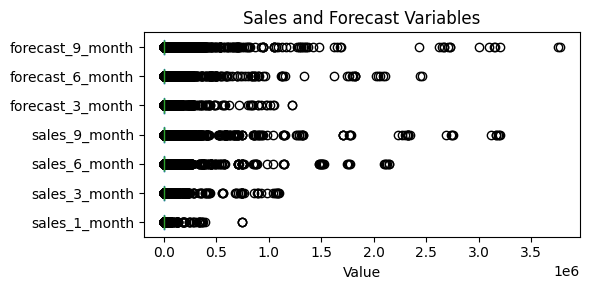

In [8]:
import matplotlib.pyplot as plt
# Group columns by similar scales for readable plots
sales_forecast = ['sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month',
                  'forecast_3_month', 'forecast_6_month', 'forecast_9_month']
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

df_backorder_raw[sales_forecast].plot(kind='box', vert=False, ax=ax)
ax.set_title('Sales and Forecast Variables')
ax.set_xlabel('Value')
plt.tight_layout()
plt.show()

The current inventory level and performace average shows negative values and understanding these further by looking at the data.

In [9]:

# Display settings
pd.set_option('display.max_rows', 50)
df_backorder_raw[df_backorder_raw['national_inv']< 0]

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
176,1111655,-55,8.0,2,428,526,606,25,100,205,...,0,-99.00,-99.00,56,No,No,No,Yes,No,Yes
191,1111670,-499,12.0,350,3452,5044,7188,747,2550,3572,...,0,0.49,0.72,525,No,No,No,Yes,No,Yes
342,1111821,-48,8.0,97,67,85,115,19,87,165,...,0,0.47,0.47,60,Yes,No,No,Yes,No,No
552,1112031,-1,12.0,0,6,6,6,0,1,2,...,0,0.82,0.79,1,No,No,No,Yes,No,No
916,1112396,-94,9.0,80,5,8,8,205,205,205,...,0,0.91,0.74,0,No,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039749,1398295,-4,NaN,0,0,0,0,0,9,25,...,0,-99.00,-99.00,0,No,No,No,No,No,No
1039835,1398384,-85,12.0,0,126,126,126,0,110,141,...,0,0.00,0.01,0,No,No,No,Yes,No,Yes
1040249,1398825,-6,NaN,0,0,0,0,3,14,49,...,0,-99.00,-99.00,0,No,No,Yes,Yes,No,No
1042276,1400992,-2,NaN,7,0,0,0,4,21,44,...,0,-99.00,-99.00,3,No,No,No,No,No,No


Analysing the relationship between national_inv < 0 and the went_on_backorder column.

In [10]:
# Analyze products with negative national inventory
negative_inventory_rows = df_backorder_raw[df_backorder_raw['national_inv'] < 0]
total_neg_inv_count = negative_inventory_rows.shape[0]

neg_inv_backorder_yes = negative_inventory_rows[negative_inventory_rows['went_on_backorder'] == 'Yes'].shape[0]
neg_inv_backorder_no = negative_inventory_rows[negative_inventory_rows['went_on_backorder'] == 'No'].shape[0]

percentage_neg_inv_backorder_yes = np.round((neg_inv_backorder_yes / total_neg_inv_count * 100), 2)
percentage_neg_inv_backorder_no = np.round((neg_inv_backorder_no / total_neg_inv_count * 100), 2)

print("Negative inventory Level Details\n")
print("Total rows with negative inventory: ",total_neg_inv_count)
print("Went on backorder:", neg_inv_backorder_yes, "(",percentage_neg_inv_backorder_yes, "%)")
print("Did not go on backorder:", neg_inv_backorder_no, "(",percentage_neg_inv_backorder_no, "%)","\n")

pos_inv_backorder_yes = df_backorder_raw[(df_backorder_raw['national_inv'] >= 0) & (df_backorder_raw['went_on_backorder'] == 'Yes')].shape[0]
print("Non-Negative inventory backorders \n")
print("Products with national_inv >= 0 that went on backorder:", pos_inv_backorder_yes,"\n")

total_dataset_rows = df_backorder_raw.shape[0]
total_backorders = neg_inv_backorder_yes + pos_inv_backorder_yes
overall_backorder_rate = np.round((total_backorders / total_dataset_rows * 100), 4)

print("Overall dataset\n")
print("Total rows in dataset:", total_dataset_rows)
print("Total backorders", total_backorders)
print("Overall backorder rate:", overall_backorder_rate)

print("\nComparison of backorder rates\n")
print("Backorder rate for Negative Inventory products:", percentage_neg_inv_backorder_yes,"%")
total_non_neg_inv_rows = total_dataset_rows - total_neg_inv_count
non_neg_inv_backorder_rate = np.round((pos_inv_backorder_yes / total_non_neg_inv_rows * 100), 4)
print("Backorder rate for Non-Negative Inventory products:", non_neg_inv_backorder_rate,"%")


Negative inventory Level Details

Total rows with negative inventory:  3785
Went on backorder: 678 ( 17.91 %)
Did not go on backorder: 3107 ( 82.09 %) 

Non-Negative inventory backorders 

Products with national_inv >= 0 that went on backorder: 8222 

Overall dataset

Total rows in dataset: 1048575
Total backorders 8900
Overall backorder rate: 0.8488

Comparison of backorder rates

Backorder rate for Negative Inventory products: 17.91 %
Backorder rate for Non-Negative Inventory products: 0.787 %


The above analysis shows that Negative Invetory levels are ~22 times more likely to go on backorder. These negative inventory levels analysis shows that most of the at-risk products are fulfilled before going to backorder


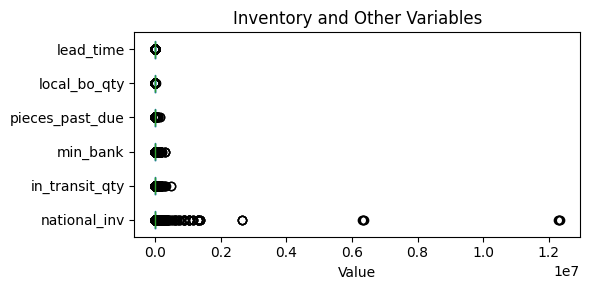

In [11]:
inv = ['national_inv', 'in_transit_qty', 'min_bank',
       'pieces_past_due', 'local_bo_qty', 'lead_time']

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df_backorder_raw[inv].plot(kind='box', vert=False, ax=ax)
ax.set_title('Inventory and Other Variables')
ax.set_xlabel('Value')

plt.tight_layout()
plt.show()

The above box plot also shows some extreme in stock quantities for certain products.

Analysing the negative values in perf_6_month_avg, perf_12_month_avg

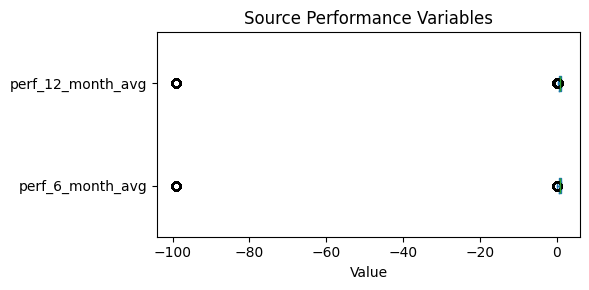

In [12]:
perf = ['perf_6_month_avg', 'perf_12_month_avg']
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
df_backorder_raw[perf].plot(kind='box', vert=False, ax=ax)
ax.set_title('Source Performance Variables')
ax.set_xlabel('Value')
plt.tight_layout()
plt.show()

No rows between 0 and -99 and some rows are exactly -99. Most of values are concentrated between 0 and 1 with a maximum vlaue of 1. This strongly suggests that the isolated -99 value is a code for may be a missing or unkown value and not a measurement. The median is not impacted by extreme outliers and a value of around 0.80 indicates most of the suppliers are reliable.

**Categorical Variable Analysis**

For each risk flag, we analyzed the proportion of flagged items that actually resulted in a backorder state

In [18]:
cat_predictors = ['potential_issue', 'deck_risk', 'oe_constraint',
                  'ppap_risk', 'stop_auto_buy', 'rev_stop']
for col in cat_predictors:
    print("\nAnalysis for: ", col, "\n")
    # Create cross-tab
    ct = pd.crosstab(df_backorder_raw[col], df_backorder_raw['went_on_backorder'], margins=True, margins_name="Total")

    # Calculate percentages for both 'No' and 'Yes' outcomes
    ct_pct = ct.div(ct['Total'], axis=0).multiply(100).round(2)

    # Combine counts and percentages for a clear view
    combined = pd.concat([ct, ct_pct.rename(columns={'No': 'No (%)', 'Yes': 'Yes (%)'})[['No (%)', 'Yes (%)']]], axis=1)

    display(combined[['No', 'No (%)', 'Yes', 'Yes (%)', 'Total']])


Analysis for:  potential_issue 



went_on_backorder,No,No (%),Yes,Yes (%),Total
potential_issue,,,,,
No,1039042,99.15,8861,0.85,1047903
Yes,633,94.20,39,5.80,672
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  deck_risk 



went_on_backorder,No,No (%),Yes,Yes (%),Total
deck_risk,,,,,
No,788209,99.08,7349,0.92,795558
Yes,251466,99.39,1551,0.61,253017
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  oe_constraint 



...

went_on_backorder,No,No (%),Yes,Yes (%),Total
ppap_risk,,,,,
No,913616,99.19,7495,0.81,921111
Yes,126059,98.90,1405,1.10,127464
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  stop_auto_buy 



went_on_backorder,No,No (%),Yes,Yes (%),Total
stop_auto_buy,,,,,
No,36585,99.05,351,0.95,36936
Yes,1003090,99.15,8549,0.85,1011639
Total,1039675,99.15,8900,0.85,1048575



Analysis for:  rev_stop 



went_on_backorder,No,No (%),Yes,Yes (%),Total
rev_stop,,,,,
No,1039217,99.15,8900,0.85,1048117
Yes,458,100.00,0,0.00,458
Total,1039675,99.15,8900,0.85,1048575


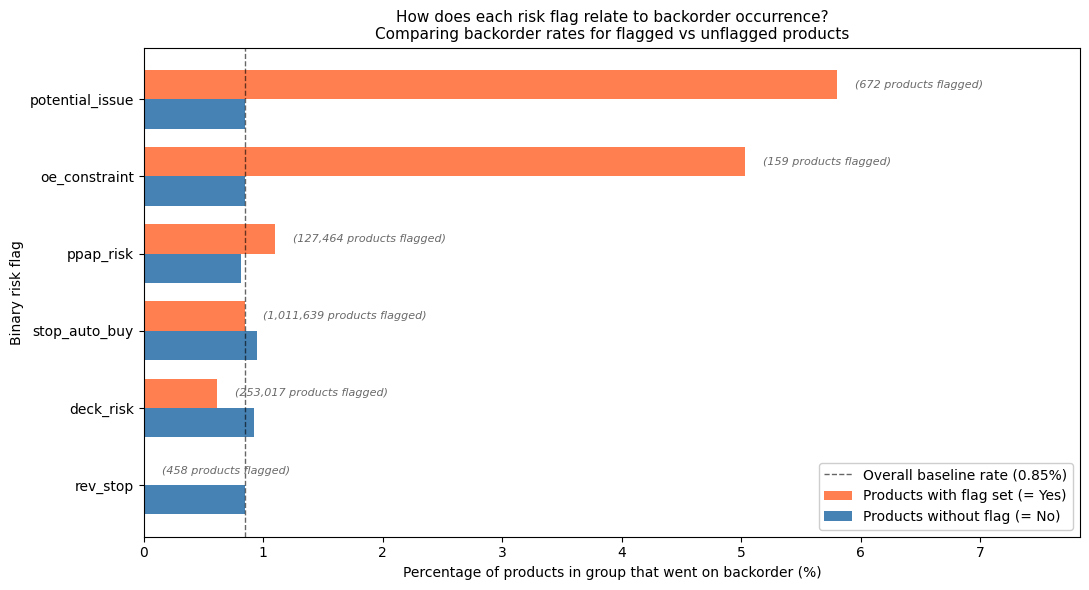

In [19]:
cat_predictors = ['potential_issue', 'deck_risk', 'oe_constraint',
                  'ppap_risk', 'stop_auto_buy', 'rev_stop']

results = []
for col in cat_predictors:
    ct = pd.crosstab(df_backorder_raw[col], df_backorder_raw['went_on_backorder'])
    rate_yes = ct.loc['Yes', 'Yes'] / ct.loc['Yes'].sum() * 100 if 'Yes' in ct.index else 0
    rate_no  = ct.loc['No',  'Yes'] / ct.loc['No'].sum()  * 100 if 'No'  in ct.index else 0
    count_yes = ct.loc['Yes'].sum() if 'Yes' in ct.index else 0
    results.append({'flag': col, 'rate_yes': rate_yes, 'rate_no': rate_no, 'count_yes': count_yes})

results_df = pd.DataFrame(results).sort_values('rate_yes', ascending=False).reset_index(drop=True)
baseline = (df_backorder_raw['went_on_backorder'] == 'Yes').mean() * 100

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(results_df))
height = 0.38

ax.barh(y_pos - height/2, results_df['rate_yes'], height,
        label='Products with flag set (= Yes)', color='coral')
ax.barh(y_pos + height/2, results_df['rate_no'], height,
        label='Products without flag (= No)', color='steelblue')

ax.axvline(baseline, color='black', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Overall baseline rate ({baseline:.2f}%)')

# Show counts only on the "Yes" bars since that's the rarer/more notable group
for i, row in results_df.iterrows():
    ax.text(row['rate_yes'] + 0.15, i - height/2,
            f"({int(row['count_yes']):,} products flagged)",
            va='center', fontsize=8, color='dimgray', style='italic')

ax.set_yticks(y_pos)
ax.set_yticklabels(results_df['flag'])
ax.set_xlabel('Percentage of products in group that went on backorder (%)')
ax.set_ylabel('Binary risk flag')
ax.set_title('How does each risk flag relate to backorder occurrence?\n'
             'Comparing backorder rates for flagged vs unflagged products',
             fontsize=11)
ax.legend(loc='lower right', framealpha=0.95)
ax.invert_yaxis()
ax.set_xlim(0, max(results_df['rate_yes']) * 1.35)  # headroom for annotations

plt.tight_layout()
plt.show()

The above chart shows all six binary predictors ordered top to down from most predictive to least predictive. The X axis represents the percentage of products that went on backorder within each indicators. The dotted line represents overall backorder rate in the dataset.

Potential_issue: Out of 672 products that have a potential_issue, 5.8% went on backorder. And of all products without a potential issue, 0.85% went on backorder. This means products flagged with potential_issue are about 6.8 times more likely to backorder than an unflagged product.
oe_constraint: Same as above. 5.9 times more likely to backorder than an unflagged product. However both predictors have small flagged subset  and therefore limits how much overall signal these contribute.

deck_risk: The products that are flagged with deck_risk is associated with lower backorder risk. This may be due to close monitoring or careful operational handling.

rev_stop: rev_stop can mean the products are blocked for sale due to revenue reason and therefore as data shows, they might be excluded from normal order fufilment.

stop_auto_buy: for most of the products this feature has been enabled and there is not much influence on the target variable.

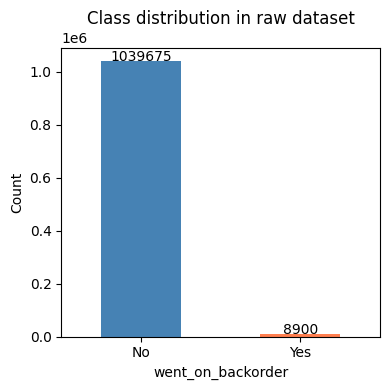


Class balance: 0.85 % Yes, 99.15 % No


In [32]:
target_counts = df_backorder_raw['went_on_backorder'].value_counts()
total = len(df_backorder_raw)

fig, ax = plt.subplots(figsize=(4, 4))
target_counts.plot(kind='bar', color=['steelblue', 'coral'], ax=ax)
ax.set_title('Class distribution in raw dataset')
ax.set_xlabel('went_on_backorder')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# Annotate each bar with its count
for i in range(len(target_counts)):
    ax.text(i, target_counts.iloc[i] + 50, str(target_counts.iloc[i]), ha='center')

plt.tight_layout()
plt.show()

print("\nClass balance:",
      round(target_counts['Yes'] / total * 100, 2), "% Yes,",
      round(target_counts['No'] / total * 100, 2), "% No")

### **Summary of Analysis**

1. The -99 code in perf_6_month_avg and perf_12_month_avg
Preprocessing Recommended:
Replace -99 with NaN so subsequent operations recognise it as missing.
Create a missing-indicator column. After splitting train/test, impute NaNs with the training-set median of each column.

2. NaN values in lead_time
Preprocessing Recommended:
Add a lead_time_was_missing indicator
Impute with the training-set median.

3. Negative national_inv values
Preprocessing Recommended:
Leave the negative values alone as they are operationally meaningful and not errors.

4. Extreme right-skew in sales, forecast, and inventory variables
Preprocessing Recommended:
For linear models like Logistic Regression, apply log1p transformation which handles zeros.
For tree-based models: no transformation needed. Trees are scale invariant and handle skew natively.

5. Massive scale disparity between features
Preprocessing:
standardisation is essential.

6. Binary categorical flags  Yes/No strings
Encode as 0/1 integers

7. SKU column is just an identifier
Means and stds of SKU are meaningless.
Preprocessing:
Drop the column before modelling.

8. Severe class imbalance
Preprocessing:
the paper used random downsampling


9. Target variable as Yes/No strings
Finding: went_on_backorder is stored as Yes/No.
Preprocessing:
Encode as 0/1

## **Methodology**

### **Preprocessing**

We can make several improvements to the paper as such in preprocessing steps as well as dealing with class imbalances.

However, we are replicating the same preprocessing steps as implemented in the paper.

1. Drop sku column
2. Encode 6 binary flags
3. Encode target variable
4. Drop rows with NaN in lead_time - Paper Choice
5. Paper doesn't mention about -99 code in perf columns. But we are dealing with it by replacing -99 with NaN and create a missing-indicator column. After splitting train/test, impute NaNs with the training-set median of each column.
6. Split train/test: 80/20 stratified
7. Random downsample training set to balance classes
8. Standardise all numeric features: fit on train, apply to test
9. Train models
10. Evaluate on imbalanced test set

